In [1]:
# Cargamos librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Tomamos la tabla que contiene las galaxias en el snap 28 (z = 0)

data = pd.read_csv('data/MuestraMZR_NoAGNL0050N0752_snap_28.dat')

In [4]:
data.head()

,GalaxyID,GroupID,SnapNum,SubGroupNumber,Stars_Mass,BlackHoleMass,SF_Mass,SF_Oxygen,SF_Hydrogen
0,1620592,28000000000014,28,0,2.756609e+11,0.0,3.262996e+09,0.033660,0.553539
1,1629768,28000000000014,28,2,1.553485e+11,0.0,5.437827e+09,0.031572,0.566845
2,1650810,28000000000014,28,1,1.453679e+11,0.0,2.118442e+10,0.014370,0.673722
3,3126435,28000000000135,28,0,3.912528e+10,0.0,6.011917e+09,0.014139,0.675768
4,3131127,28000000000136,28,0,1.317595e+10,0.0,1.731854e+09,0.014267,0.674644


In [5]:
# Longitud de registros
print('Total de registros:', len(data)) # Condiciones sub.SnapNum=28 and sub.BlackHoleMass>0 and sub.Stars_Mass>10000000000.0 and sub.SF_Oxygen>0 and sub.SF_Hydrogen>0 
print('Total de registros siendo centrales:', len(data[data['SubGroupNumber']==0])) # Condiciones sub.SnapNum=28 and sub.SubGroupNumber=0 and sub.BlackHoleMass>0 and sub.Stars_Mass>10000000000.0 and sub.SF_Oxygen>0 and sub.SF_Hydrogen>0    


Total de registros: 466
Total de registros siendo centrales: 320


In [6]:
# Nos concentramos en las galaxias centrales (SubGroupNumber=0). POsteriormente se podrían incluir las demás para el estudio del medio ambiente.
data_centrales = data[data['SubGroupNumber']==0]

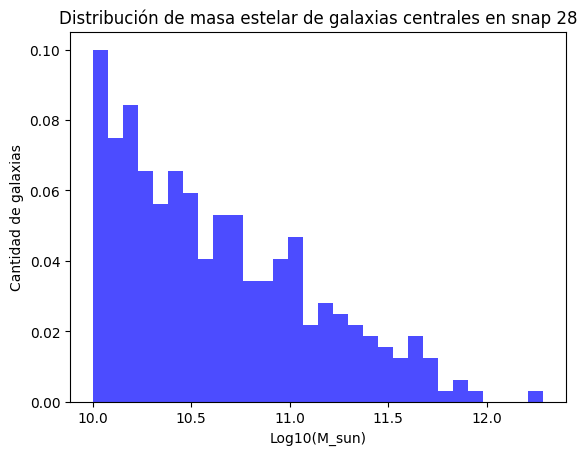

In [7]:
# Reaizamos un histograma de la masa estelar de las galaxias centrales.
plt.hist(np.log10(data_centrales['Stars_Mass']),weights=np.ones_like(data_centrales['Stars_Mass']) / len(data_centrales['Stars_Mass']), bins=30, log=False, density=False, alpha=0.7, color='blue')
plt.xlabel('Log10(M_sun)')
plt.ylabel('Cantidad de galaxias')
plt.title('Distribución de masa estelar de galaxias centrales en snap 28')
plt.show()

In [9]:
#No hay BH en esta muestra, por lo que no se puede realizar un histograma de la masa de los agujeros

# Reaizamos un histograma de la masa BH de las galaxias centrales.
#plt.hist(np.log10(data_centrales['BlackHoleMass']),weights=np.ones_like(data_centrales['BlackHoleMass']) / len(data_centrales['BlackHoleMass']), bins=30, log=False, density=False, alpha=0.7, color='blue')
#plt.xlabel('Log10(M_BH)')
#plt.ylabel('Cantidad de galaxias')
#plt.title('Distribución de masa de agujeros negros de galaxias centrales en snap 28')
#plt.show()

In [10]:
# Definimos la abundancia de O como:

data_centrales['metalicidad'] = 12 + np.log10(data_centrales['SF_Oxygen']) - np.log10(data_centrales['SF_Hydrogen']) - np.log10(16)

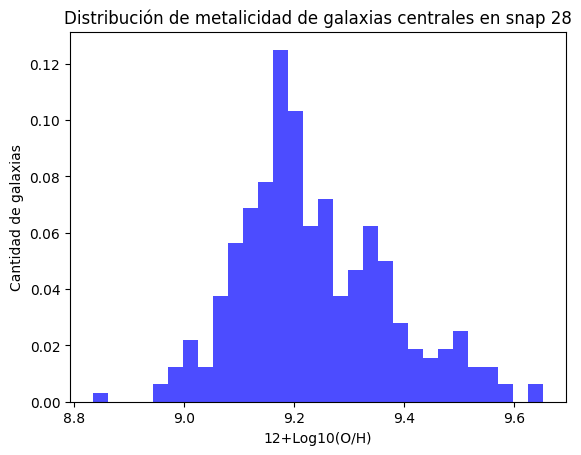

In [11]:
# Realizamos el histogama para la metalicidad
plt.hist(data_centrales['metalicidad'], weights=np.ones_like(data_centrales['metalicidad']) / len(data_centrales['metalicidad']), bins=30, log=False, density=False, alpha=0.7, color='blue')
plt.xlabel('12+Log10(O/H)')
plt.ylabel('Cantidad de galaxias')
plt.title('Distribución de metalicidad de galaxias centrales en snap 28')
plt.show()

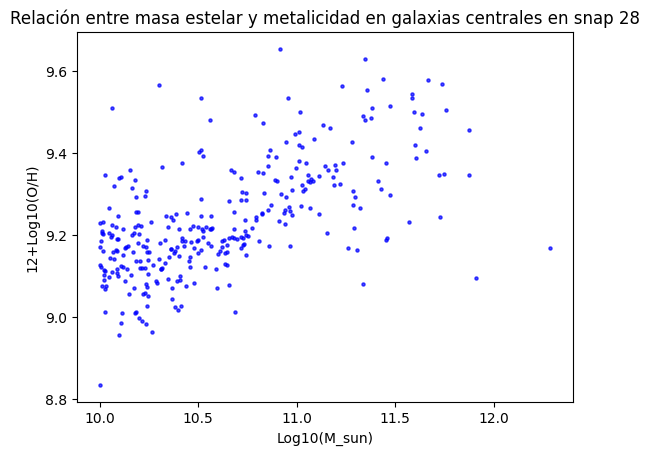

In [12]:
# Hacemos el scatter plot de la metalicidad en función de la masa estelar

plt.scatter(np.log10(data_centrales['Stars_Mass']), data_centrales['metalicidad'], alpha=0.7, color='blue', s=5)
plt.xlabel('Log10(M_sun)')
plt.ylabel('12+Log10(O/H)')
plt.title('Relación entre masa estelar y metalicidad en galaxias centrales en snap 28')
plt.show()

In [13]:
# Tampoco hacemos el scatter plot de la metalicidad en función de M_BH.

# Hacemos el scatter plot de la metalicidad en finción de la masa BH

#plt.scatter(np.log10(data_centrales['BlackHoleMass']), data_centrales['metalicidad'], alpha=0.7, color='blue', s=5)
#plt.xlabel('Log10(M_BH)')
#plt.ylabel('12+Log10(O/H)')
#plt.title('Relación entre masa estelar y metalicidad en galaxias centrales en snap 28')
#plt.show()

In [14]:
# Guardamos la tabla de galaxias centrales en el plano MZR con M>10^10 M_sun
data_centrales.to_csv('data/data_centrales_NoAGNL050N0752_snap28.csv', index=False)

In [ ]:
# --------------------------------------------------------------------------------------------